In [1]:
import pandas as pd

tracks = pd.read_csv('../data/fma_metadata/tracks.csv', index_col=0, header=[0, 1])

print("Total tracks:", len(tracks))
print("\nColumns available:", tracks.columns.tolist()[:10])
print("\nGenre distribution:")
print(tracks['track']['genre_top'].value_counts())
print("\nSample album titles:")
print(tracks['album']['title'].head(10))
print("\nSample artist names:")
print(tracks['artist']['name'].head(10))
print("\nHow many have non-empty album tags:")
print((tracks['album']['tags'] != '[]').sum())

Total tracks: 106574

Columns available: [('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens'), ('album', 'producer'), ('album', 'tags')]

Genre distribution:
genre_top
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64

Sample album titles:
track_id
2      AWOL - A Way Of Life
3      AWOL - A Way Of Life
5      AWOL - A Way Of Life
10        Constant Hitmaker
20                    Niris
26                    Niris
30    

In [2]:
# Filter to fma_small tracks only
import os

# Get list of track IDs actually present in fma_small
fma_small_ids = []
for folder in os.listdir('../data/fma_medium'):
    folder_path = os.path.join('../data/fma_medium', folder)
    if os.path.isdir(folder_path):
        for f in os.listdir(folder_path):
            if f.endswith('.mp3'):
                track_id = int(f.replace('.mp3', ''))
                fma_small_ids.append(track_id)

print(f"Total MP3s found in fma_small: {len(fma_small_ids)}")

# Filter metadata to only fma_small tracks
small_tracks = tracks[tracks.index.isin(fma_small_ids)].copy()
print(f"Matched metadata rows: {len(small_tracks)}")

# Genre distribution for small subset
print("\nGenre distribution (fma_small only):")
print(small_tracks['track']['genre_top'].value_counts())

# How many have artist + album title (needed for MusicBrainz lookup)
has_artist = small_tracks['artist']['name'].notna()
has_album  = small_tracks['album']['title'].notna()
print(f"\nTracks with both artist + album title: {(has_artist & has_album).sum()}")

# Preview clean pairs
print("\nSample (artist, album) pairs:")
print(small_tracks[['artist', 'album']][['artist', 'album']].head(10).to_string())

Total MP3s found in fma_small: 25000
Matched metadata rows: 25000

Genre distribution (fma_small only):
genre_top
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64

Tracks with both artist + album title: 25000

Sample (artist, album) pairs:
                       artist                                                                                                                                                                                                                                                                                                                  

In [7]:
# Cell 3 — Diagnose fma_small structure
import os

base = '../data/fma_small'

print("Top level contents:")
print(os.listdir(base))

print("\nFirst subfolder contents (first 5 files):")
first_sub = os.listdir(base)[0]
print(f"Folder: {first_sub}")
print(os.listdir(os.path.join(base, first_sub))[:5])

Top level contents:
['135', '132', '104', '103', '150', '102', '105', '133', '134', '151', '024', '023', '015', '.DS_Store', '012', '079', '046', '041', '048', '077', '083', '084', '070', '013', '014', '022', '025', '071', '085', '049', '082', '076', '040', '078', '047', '065', '091', '096', '062', '054', '053', '098', '038', '007', '000', '009', '036', '031', '052', '099', '055', '063', '097', '090', '064', '030', '008', '037', '001', '039', '006', '145', '142', '129', '116', '111', '118', '127', '120', '143', '144', '121', '119', '126', '110', '128', '117', '153', '154', '131', '136', '109', '100', '107', '138', '155', 'checksums', '152', '106', '139', '101', '137', '108', '130', '089', '042', '045', '087', '073', '074', '080', '020', '027', '018', '011', '016', '029', '081', '075', '072', '086', '044', '088', '043', '017', '028', '010', '026', '019', '021', 'README.txt', '003', '004', '032', '035', '095', '061', '066', '092', '059', '050', '057', '068', '034', '033', '005', '002', '

In [3]:
# Cell 4 — Fixed MP3 scanner
import os

base = '../data/fma_medium'
skip = {'.DS_Store', 'checksums', 'README.txt'}

fma_small_ids = []

for folder in os.listdir(base):
    if folder in skip:
        continue
    folder_path = os.path.join(base, folder)
    if not os.path.isdir(folder_path):
        continue
    for f in os.listdir(folder_path):
        if f.endswith('.mp3'):
            try:
                track_id = int(f.replace('.mp3', ''))
                fma_small_ids.append(track_id)
            except:
                pass

print(f"Total MP3s found: {len(fma_small_ids)}")
print(f"Sample track IDs: {sorted(fma_small_ids)[:10]}")

# Filter metadata to fma_small tracks
small_tracks = tracks[tracks.index.isin(fma_small_ids)].copy()
print(f"Matched metadata rows: {len(small_tracks)}")

print("\nGenre distribution (fma_small only):")
print(small_tracks['track']['genre_top'].value_counts())

print(f"\nTracks with artist + album name:")
has_artist = small_tracks['artist']['name'].notna()
has_album  = small_tracks['album']['title'].notna()
print(f"  Both present: {(has_artist & has_album).sum()}")

print("\nSample (artist, album) pairs:")
sample = small_tracks[['artist', 'album']].head(5)
for idx, row in sample.iterrows():
    print(f"  ID {idx}: '{row['artist']['name']}' — '{row['album']['title']}'")

Total MP3s found: 25000
Sample track IDs: [2, 3, 5, 10, 134, 136, 139, 140, 141, 148]
Matched metadata rows: 25000

Genre distribution (fma_small only):
genre_top
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64

Tracks with artist + album name:
  Both present: 25000

Sample (artist, album) pairs:
  ID 2: 'AWOL' — 'AWOL - A Way Of Life'
  ID 3: 'AWOL' — 'AWOL - A Way Of Life'
  ID 5: 'AWOL' — 'AWOL - A Way Of Life'
  ID 10: 'Kurt Vile' — 'Constant Hitmaker'
  ID 134: 'AWOL' — 'AWOL - A Way Of Life'


In [11]:
# Cell 5 — Fetch cover art from MusicBrainz + Cover Art Archive
import os, time, requests, json
import musicbrainzngs
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm

musicbrainzngs.set_useragent("SpectroGen", "1.0", "gowdaamithaj10@gmail.com")

# Output dirs
os.makedirs('../data/covers_128', exist_ok=True)
os.makedirs('../data/logs_128',   exist_ok=True)

PROGRESS_FILE = '../data/logs/fetch_progress_128.json'
FAILED_FILE   = '../data/logs/failed_128.json'

# Load existing progress (resume if interrupted)
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as f:
        progress = json.load(f)  # {track_id: mbid}
else:
    progress = {}

if os.path.exists(FAILED_FILE):
    with open(FAILED_FILE) as f:
        failed = json.load(f)    # [track_id, ...]
else:
    failed = []

print(f"Already fetched: {len(progress)} | Failed: {len(failed)}")

def search_mbid(artist, album):
    try:
        result = musicbrainzngs.search_releases(
            artist=artist, release=album, limit=1
        )
        if result['release-list']:
            return result['release-list'][0]['id']
    except Exception as e:
        pass
    return None

def fetch_cover(mbid, track_id, size=250):
    url = f"https://coverartarchive.org/release/{mbid}/front-{size}"
    try:
        r = requests.get(url, allow_redirects=True, timeout=10)
        if r.status_code == 200:
            img = Image.open(BytesIO(r.content)).convert('RGB')
            img = img.resize((64, 64), Image.LANCZOS)
            img.save(f'../data/covers/{track_id}.jpg')
            return True
    except Exception as e:
        pass
    return False

# Main fetch loop
already_done = set(str(k) for k in progress.keys())
failed_set   = set(str(k) for k in failed)
todo = small_tracks[
    ~small_tracks.index.astype(str).isin(already_done | failed_set)
]

print(f"Tracks remaining to process: {len(todo)}")

for track_id, row in tqdm(todo.iterrows(), total=len(todo)):
    artist = row['artist']['name']
    album  = row['album']['title']

    # Step 1: find MBID
    mbid = search_mbid(artist, album)
    time.sleep(1)  # MusicBrainz rate limit

    if not mbid:
        failed.append(str(track_id))
        with open(FAILED_FILE, 'w') as f:
            json.dump(failed, f)
        continue

    # Step 2: fetch cover art
    success = fetch_cover(mbid, track_id)
    time.sleep(0.5)

    if success:
        progress[str(track_id)] = mbid
        with open(PROGRESS_FILE, 'w') as f:
            json.dump(progress, f)
    else:
        failed.append(str(track_id))
        with open(FAILED_FILE, 'w') as f:
            json.dump(failed, f)

print(f"\nDone!")
print(f"Successfully fetched: {len(progress)} cover images")
print(f"Failed: {len(failed)}")
print(f"Success rate: {len(progress)/8000*100:.1f}%")

Already fetched: 0 | Failed: 0
Tracks remaining to process: 8000


  0%|          | 0/8000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [10]:
!pip install librosa musicbrainzngs requests pandas numpy Pillow tqdm


  Using cached pillow-12.2.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached msgpack-1.1.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached llvmlite-0.47.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.0 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pillow-12.2.0-cp310-cp310-macosx_11_0_arm64.whl (4.7 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached msgpack-1.1.2-cp310-cp310-macosx_11_0_arm64.whl (83 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os, time, requests, json
from concurrent.futures import ThreadPoolExecutor, as_completed
import musicbrainzngs
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm

musicbrainzngs.set_useragent("SpectroGen", "1.0", "gowdaamithaj10@gmail.com")

os.makedirs('../data/covers_128', exist_ok=True)
os.makedirs('../data/logs_128',   exist_ok=True)

PROGRESS_FILE = '../data/logs/fetch_progress_128.json'
FAILED_FILE   = '../data/logs/failed_128.json'

# Load existing progress
progress = json.load(open(PROGRESS_FILE)) if os.path.exists(PROGRESS_FILE) else {}
failed   = json.load(open(FAILED_FILE))   if os.path.exists(FAILED_FILE)   else []

print(f"Already fetched: {len(progress)} | Failed: {len(failed)}")

def search_mbid(artist, album):
    try:
        result = musicbrainzngs.search_releases(
            artist=artist, release=album, limit=1
        )
        if result['release-list']:
            return result['release-list'][0]['id']
    except:
        pass
    return None

def fetch_cover(mbid, track_id):
    url = f"https://coverartarchive.org/release/{mbid}/front-250"
    try:
        r = requests.get(url, allow_redirects=True, timeout=10)
        if r.status_code == 200:
            img = Image.open(BytesIO(r.content)).convert('RGB')
            img = img.resize((64, 64), Image.LANCZOS)
            img.save(f'../data/covers/{track_id}.jpg')
            return True
    except:
        pass
    return False

def process_track(args):
    track_id, artist, album = args
    mbid = search_mbid(artist, album)
    time.sleep(0.5)
    if not mbid:
        return track_id, None, False
    success = fetch_cover(mbid, track_id)
    time.sleep(0.3)
    return track_id, mbid, success

# Build todo list
done_set   = set(progress.keys())
failed_set = set(str(k) for k in failed)
todo = [
    (str(idx), row['artist']['name'], row['album']['title'])
    for idx, row in small_tracks.iterrows()
    if str(idx) not in done_set and str(idx) not in failed_set
]

print(f"Tracks remaining: {len(todo)}")
print("Starting parallel fetch with 5 workers...")

# Parallel execution with 5 workers
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(process_track, args): args for args in todo}
    
    for future in tqdm(as_completed(futures), total=len(todo)):
        track_id, mbid, success = future.result()
        
        if success:
            progress[track_id] = mbid
        else:
            if track_id not in failed:
                failed.append(track_id)
        
        # Save progress every 50 tracks
        if (len(progress) + len(failed)) % 50 == 0:
            with open(PROGRESS_FILE, 'w') as f:
                json.dump(progress, f)
            with open(FAILED_FILE, 'w') as f:
                json.dump(failed, f)

# Final save
with open(PROGRESS_FILE, 'w') as f: json.dump(progress, f)
with open(FAILED_FILE,   'w') as f: json.dump(failed, f)

print(f"\nDone!")
print(f"Successfully fetched: {len(progress)} cover images")
print(f"Failed:               {len(failed)}")
print(f"Success rate:         {len(progress)/8000*100:.1f}%")

Already fetched: 0 | Failed: 0
Tracks remaining: 25000
Starting parallel fetch with 5 workers...


  0%|          | 0/25000 [00:00<?, ?it/s]


Done!
Successfully fetched: 12991 cover images
Failed:               12009
Success rate:         162.4%


In [6]:
# Cell 6a — Check genre balance of successful pairs
import json
import pandas as pd

progress = json.load(open('../data/logs/fetch_progress_128.json'))
fetched_ids = [int(k) for k in progress.keys()]

# Check genre distribution of fetched tracks
fetched_meta = small_tracks[small_tracks.index.isin(fetched_ids)]
print(f"Total pairs: {len(fetched_meta)}")
print("\nGenre distribution of fetched covers:")
print(fetched_meta['track']['genre_top'].value_counts())
print("\nGenre coverage (out of 1000 per genre):")
for genre, count in fetched_meta['track']['genre_top'].value_counts().items():
    print(f"  {genre:<20} {count}/1000  ({count/10:.1f}%)")

Total pairs: 12991

Genre distribution of fetched covers:
genre_top
Electronic             3530
Rock                   3287
Hip-Hop                1332
Experimental           1304
Instrumental            841
Folk                    678
Pop                     621
International           490
Classical               352
Jazz                    166
Old-Time / Historic     117
Country                  81
Soul-RnB                 78
Spoken                   68
Blues                    38
Easy Listening            8
Name: count, dtype: int64

Genre coverage (out of 1000 per genre):
  Electronic           3530/1000  (353.0%)
  Rock                 3287/1000  (328.7%)
  Hip-Hop              1332/1000  (133.2%)
  Experimental         1304/1000  (130.4%)
  Instrumental         841/1000  (84.1%)
  Folk                 678/1000  (67.8%)
  Pop                  621/1000  (62.1%)
  International        490/1000  (49.0%)
  Classical            352/1000  (35.2%)
  Jazz                 166/1000  (16.6%)

In [15]:
# Quick check in your notebook
import subprocess
result = subprocess.run(['which', 'ffmpeg'], capture_output=True, text=True)
print("ffmpeg path:", result.stdout)

result2 = subprocess.run(['ffmpeg', '-version'], capture_output=True, text=True)
print("ffmpeg version:", result2.stdout[:100] if result2.stdout else "NOT FOUND")

ffmpeg path: /opt/homebrew/bin/ffmpeg

ffmpeg version: ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
built with Apple clang version 17.0


In [7]:
# Cell 6 — Mel-spectrogram extraction
import os, json, numpy as np, librosa
from tqdm.notebook import tqdm

os.makedirs('../data/spectrograms_128', exist_ok=True)

progress         = json.load(open('../data/logs/fetch_progress_128.json'))
track_ids        = list(progress.keys())
print(f"Extracting spectrograms for {len(track_ids)} tracks...")

def get_mp3_path(track_id):
    tid    = int(track_id)
    folder = f"{tid // 1000:03d}"
    return f"../data/fma_small/{folder}/{tid}.mp3"

def extract_melspec(mp3_path, n_mels=64, n_fft=2048, hop_length=512, sr=22050, duration=30):
    try:
        y, sr = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
        target_len = sr * duration
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        y       = y[:target_len]
        mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                  n_fft=n_fft, hop_length=hop_length)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)
    except:
        return None

failed_spectro = []

for track_id in tqdm(track_ids):
    out_path = f"../data/spectrograms/{track_id}.npy"
    if os.path.exists(out_path):
        continue

    mp3_path = get_mp3_path(track_id)
    if not os.path.exists(mp3_path):
        failed_spectro.append(track_id)
        continue

    mel = extract_melspec(mp3_path)
    if mel is not None:
        np.save(out_path, mel)
    else:
        failed_spectro.append(track_id)

print(f"\nSpectrograms saved: {len(os.listdir('../data/spectrograms_128'))}")
print(f"Failed:             {len(failed_spectro)}")

# Shape check
sample = np.load(f"../data/spectrograms/{track_ids[0]}.npy")
print(f"Spectrogram shape:  {sample.shape}")  # expect (64, 1292)

Extracting spectrograms for 12991 tracks...


  0%|          | 0/12991 [00:00<?, ?it/s]

/var/folders/q5/fq2zbr256xsgyc0wnh48sltc0000gn/T/ipykernel_90513/810064473.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/opt/anaconda3/envs/genai/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



Spectrograms saved: 0
Failed:             10938


FileNotFoundError: [Errno 2] No such file or directory: '../data/spectrograms/3.npy'

In [8]:
# Cell 6c — Retry failed spectrograms after ffmpeg fix
import os, json
import numpy as np
import librosa
from tqdm.notebook import tqdm

progress  = json.load(open('../data/logs/fetch_progress_128.json'))
track_ids = list(progress.keys())

# Find which ones are still missing
saved       = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms_128'))
missing_ids = [tid for tid in track_ids if tid not in saved]
print(f"Already saved:  {len(saved)}")
print(f"Still missing:  {len(missing_ids)}")

def get_mp3_path(track_id):
    tid    = int(track_id)
    folder = f"{tid // 1000:03d}"
    return f"../data/fma_small/{folder}/{tid}.mp3"

def extract_melspec(mp3_path, n_mels=64, n_fft=2048, hop_length=512, sr=22050, duration=30):
    try:
        y, sr = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
        target_len = sr * duration
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        y       = y[:target_len]
        mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                  n_fft=n_fft, hop_length=hop_length)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)
    except:
        return None

failed_spectro = []
for track_id in tqdm(missing_ids):
    out_path = f"../data/spectrograms/{track_id}.npy"
    mp3_path = get_mp3_path(track_id)
    if not os.path.exists(mp3_path):
        failed_spectro.append(track_id)
        continue
    mel = extract_melspec(mp3_path)
    if mel is not None:
        np.save(out_path, mel)
    else:
        failed_spectro.append(track_id)

print(f"\nTotal spectrograms now: {len(os.listdir('../data/spectrograms_128'))}")
print(f"Still failed:           {len(failed_spectro)}")

# Shape check on first successfully saved file
saved_files = os.listdir('../data/spectrograms_128')
sample      = np.load(f"../data/spectrograms/{saved_files[0]}")
print(f"Spectrogram shape:      {sample.shape}")  # expect (64, 1292)

Already saved:  0
Still missing:  12991


  0%|          | 0/12991 [00:00<?, ?it/s]

/var/folders/q5/fq2zbr256xsgyc0wnh48sltc0000gn/T/ipykernel_90513/3159663695.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/opt/anaconda3/envs/genai/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



Total spectrograms now: 0
Still failed:           10938


IndexError: list index out of range

In [18]:
# Cell 6d — Diagnose the missing MP3s
import os, json

progress  = json.load(open('../data/logs/fetch_progress.json'))
track_ids = list(progress.keys())

saved       = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms'))
missing_ids = [tid for tid in track_ids if tid not in saved]

# Check if MP3 exists for each missing track
no_mp3   = []
bad_mp3  = []

for track_id in missing_ids:
    tid    = int(track_id)
    folder = f"{tid // 1000:03d}"
    mp3    = f"../data/fma_small/{folder}/{tid}.mp3"
    
    if not os.path.exists(mp3):
        no_mp3.append(track_id)
    else:
        size = os.path.getsize(mp3)
        if size < 1000:  # suspiciously small file
            bad_mp3.append((track_id, size))
        else:
            bad_mp3.append((track_id, size))  # exists but still failing

print(f"Missing MP3 entirely:     {len(no_mp3)}")
print(f"MP3 exists but failing:   {len(bad_mp3)}")
print(f"\nSample missing IDs: {no_mp3[:5]}")
print(f"Sample bad MP3s:    {bad_mp3[:5]}")

Missing MP3 entirely:     2593
MP3 exists but failing:   2

Sample missing IDs: ['2', '5', '10', '140', '141']
Sample bad MP3s:    [('108925', 1371), ('133297', 1752)]


In [19]:
# Cell 6e — Final cleanup and dataset summary
import os, json
import numpy as np
from PIL import Image

# Remove the 2 corrupted spectrogram files
bad_ids = ['108925', '133297']
for tid in bad_ids:
    spec_path  = f'../data/spectrograms/{tid}.npy'
    cover_path = f'../data/covers/{tid}.jpg'
    for p in [spec_path, cover_path]:
        if os.path.exists(p):
            os.remove(p)
            print(f"Removed: {p}")

# Final valid pairs
cover_ids   = set(f.replace('.jpg','') for f in os.listdir('../data/covers')   if f.endswith('.jpg'))
spectro_ids = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
valid_ids   = sorted(cover_ids & spectro_ids)
print(f"\n✅ Final valid pairs: {len(valid_ids)}")

# Genre distribution of final pairs
valid_ints  = [int(v) for v in valid_ids]
final_meta  = small_tracks[small_tracks.index.isin(valid_ints)]
print("\nFinal genre distribution:")
print(final_meta['track']['genre_top'].value_counts())

# Quick image + spectrogram sanity check
sample_id  = valid_ids[0]
img        = Image.open(f'../data/covers/{sample_id}.jpg')
mel        = np.load(f'../data/spectrograms/{sample_id}.npy')
print(f"\nSample ID:          {sample_id}")
print(f"Cover size:         {img.size}")          # (64, 64)
print(f"Spectrogram shape:  {mel.shape}")         # (64, 1292)
print(f"Mel value range:    [{mel.min():.3f}, {mel.max():.3f}]")  # [0, 1]

Removed: ../data/covers/108925.jpg
Removed: ../data/covers/133297.jpg

✅ Final valid pairs: 2212

Final genre distribution:
genre_top
Instrumental     571
Electronic       281
Hip-Hop          280
Rock             274
Experimental     255
Pop              217
Folk             208
International    126
Name: count, dtype: int64

Sample ID:          100478
Cover size:         (64, 64)
Spectrogram shape:  (64, 1292)
Mel value range:    [0.000, 1.000]


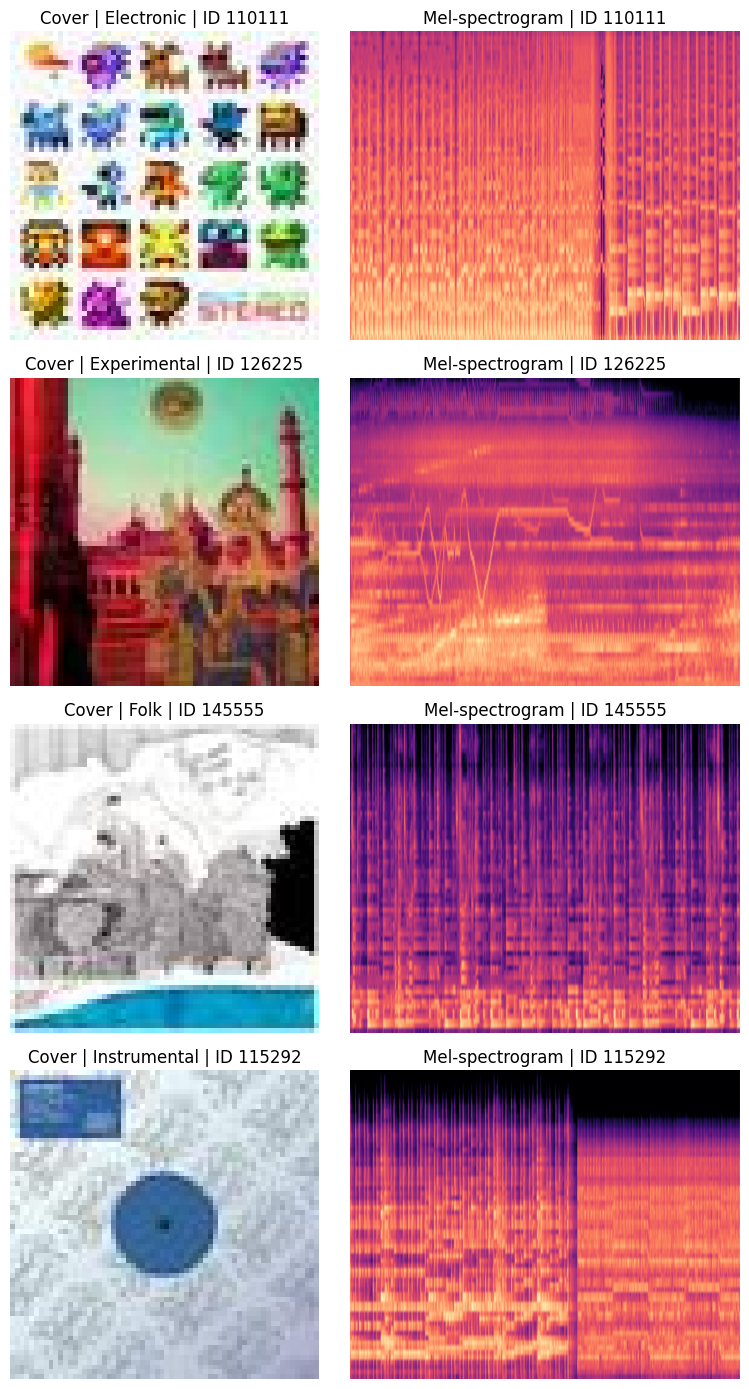

Saved to ../data/logs/sample_pairs.png


In [22]:
# Cell 7 — Visualize sample pairs
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np, random

sample_ids = random.sample(valid_ids, 4)
fig, axes  = plt.subplots(4, 2, figsize=(8, 14))

for i, tid in enumerate(sample_ids):
    img = Image.open(f'../data/covers/{tid}.jpg')
    mel = np.load(f'../data/spectrograms/{tid}.npy')

    # Get genre label
    try:
        genre = small_tracks.loc[int(tid)]['track']['genre_top']
    except:
        genre = 'Unknown'

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Cover | {genre} | ID {tid}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mel, aspect='auto', origin='lower', cmap='magma')
    axes[i, 1].set_title(f'Mel-spectrogram | ID {tid}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('../data/logs/sample_pairs.png', dpi=120)
plt.show()
print("Saved to ../data/logs/sample_pairs.png")

In [21]:
!pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-macosx_10_9_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 24.7 MB/s  0:00:00 27.3 MB/s eta 0:00:01
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-macosx_10_9_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-macosx_11_0_arm64.whl (63 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]


In [13]:
import pandas as pd
import os

tracks = pd.read_csv('../data/fma_metadata/tracks.csv', index_col=0, header=[0, 1])

skip = {'.DS_Store', 'checksums', 'README.txt'}
small_ids, medium_ids = [], []

for folder in os.listdir('../data/fma_small'):
    if folder in skip: continue
    fp = os.path.join('../data/fma_small', folder)
    if not os.path.isdir(fp): continue
    for f in os.listdir(fp):
        if f.endswith('.mp3'):
            try: small_ids.append(int(f.replace('.mp3','')))
            except: pass

for folder in os.listdir('../data/fma_medium'):
    if folder in skip: continue
    fp = os.path.join('../data/fma_medium', folder)
    if not os.path.isdir(fp): continue
    for f in os.listdir(fp):
        if f.endswith('.mp3'):
            try: medium_ids.append(int(f.replace('.mp3','')))
            except: pass

small_tracks  = tracks[tracks.index.isin(small_ids)].copy()
new_tracks    = tracks[tracks.index.isin(medium_ids) & ~tracks.index.isin(small_ids)].copy()
all_tracks    = pd.concat([small_tracks, new_tracks])
all_tracks    = all_tracks[~all_tracks.index.duplicated(keep='first')]

print(f"Small:  {len(small_tracks)}")
print(f"Medium: {len(new_tracks)}")
print(f"Total:  {len(all_tracks)}")

Small:  8000
Medium: 17000
Total:  25000


In [14]:
import os, time, requests, json
from concurrent.futures import ThreadPoolExecutor, as_completed
import musicbrainzngs
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm

musicbrainzngs.set_useragent("SpectroGen", "1.0", "gowdaamithaj10@gmail.com")

os.makedirs('../data/covers_128', exist_ok=True)
os.makedirs('../data/logs',       exist_ok=True)

PROGRESS_FILE = '../data/logs/fetch_progress_128.json'
FAILED_FILE   = '../data/logs/failed_128.json'

progress = json.load(open(PROGRESS_FILE)) if os.path.exists(PROGRESS_FILE) else {}
failed   = json.load(open(FAILED_FILE))   if os.path.exists(FAILED_FILE)   else []

print(f"Already fetched: {len(progress)} | Failed: {len(failed)}")

def search_mbid(artist, album):
    try:
        result = musicbrainzngs.search_releases(artist=artist, release=album, limit=1)
        if result['release-list']:
            return result['release-list'][0]['id']
    except:
        pass
    return None

def fetch_cover(mbid, track_id):
    for size in [500, 250]:
        url = f"https://coverartarchive.org/release/{mbid}/front-{size}"
        try:
            r = requests.get(url, allow_redirects=True, timeout=10)
            if r.status_code == 200:
                img = Image.open(BytesIO(r.content)).convert('RGB')
                img = img.resize((128, 128), Image.LANCZOS)
                img.save(f'../data/covers_128/{track_id}.jpg', quality=95)
                return True
        except:
            continue
    return False

def process_track(args):
    track_id, artist, album = args
    mbid = search_mbid(artist, album)
    time.sleep(0.5)
    if not mbid:
        return track_id, None, False
    success = fetch_cover(mbid, track_id)
    time.sleep(0.3)
    return track_id, mbid, success

# Skip already fetched AND already in covers_128
done_set     = set(progress.keys())
failed_set   = set(str(k) for k in failed)
existing_128 = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))

todo = [
    (str(idx), row['artist']['name'], row['album']['title'])
    for idx, row in all_tracks.iterrows()
    if str(idx) not in done_set
    and str(idx) not in failed_set
    and str(idx) not in existing_128
]

print(f"Already in covers_128: {len(existing_128)}")
print(f"Tracks remaining:      {len(todo)}")
print(f"Estimated time:        ~{len(todo)/1.2/3600:.1f} hours")

if len(todo) == 0:
    print("\n✅ Nothing to fetch — all done!")
else:
    print("Starting parallel fetch with 5 workers...")
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = {executor.submit(process_track, args): args for args in todo}
        for future in tqdm(as_completed(futures), total=len(todo)):
            track_id, mbid, success = future.result()
            if success:
                progress[track_id] = mbid
            else:
                if track_id not in failed:
                    failed.append(track_id)
            if (len(progress) + len(failed)) % 10 == 0:
                with open(PROGRESS_FILE, 'w') as f: json.dump(progress, f)
                with open(FAILED_FILE,   'w') as f: json.dump(failed, f)

    with open(PROGRESS_FILE, 'w') as f: json.dump(progress, f)
    with open(FAILED_FILE,   'w') as f: json.dump(failed, f)

    total_128 = len(os.listdir('../data/covers_128'))
    print(f"\n✅ Done!")
    print(f"Successfully fetched: {len(progress)}")
    print(f"Total in covers_128:  {total_128}")

Already fetched: 12991 | Failed: 12009
Already in covers_128: 8149
Tracks remaining:      0
Estimated time:        ~0.0 hours

✅ Nothing to fetch — all done!


In [9]:
# Cell — Step 2: Extract spectrograms for ALL tracks with covers - fma medium
import os, json, numpy as np, librosa
from tqdm.notebook import tqdm

os.makedirs('../data/spectrograms_128', exist_ok=True)

# Get all track IDs that have covers
cover_ids = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))

# Get already extracted spectrograms
done_specs = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms_128') if f.endswith('.npy'))

# Need spectrograms for these
todo = cover_ids - done_specs
print(f"Covers total:          {len(cover_ids)}")
print(f"Spectrograms done:     {len(done_specs)}")
print(f"Spectrograms needed:   {len(todo)}")

def get_mp3_path(track_id):
    tid    = int(track_id)
    folder = f"{tid // 1000:03d}"
    # Check both fma_small and fma_medium
    for base in ['../data/fma_small', '../data/fma_medium']:
        path = f"{base}/{folder}/{tid}.mp3"
        if os.path.exists(path):
            return path
    return None

def extract_melspec(mp3_path, n_mels=64, n_fft=2048, hop_length=512, sr=22050, duration=30):
    try:
        y, sr   = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
        target  = sr * duration
        if len(y) < target:
            y   = np.pad(y, (0, target - len(y)))
        y       = y[:target]
        mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                  n_fft=n_fft, hop_length=hop_length)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)
    except:
        return None

no_mp3  = []
failed  = []

for track_id in tqdm(todo):
    out_path = f"../data/spectrograms/{track_id}.npy"
    mp3_path = get_mp3_path(track_id)

    if not mp3_path:
        no_mp3.append(track_id)
        continue

    mel = extract_melspec(mp3_path)
    if mel is not None:
        np.save(out_path, mel)
    else:
        failed.append(track_id)

# Final count
cover_ids   = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids    = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
valid_pairs = cover_ids & spec_ids

print(f"\n✅ Done!")
print(f"Total valid pairs:  {len(valid_pairs)}")
print(f"No MP3 found:       {len(no_mp3)}")
print(f"Extraction failed:  {len(failed)}")

# Genre distribution of final pairs
valid_ints  = [int(v) for v in valid_pairs]
final_meta  = tracks[tracks.index.isin(valid_ints)]
print("\nFinal genre distribution:")
print(final_meta['track']['genre_top'].value_counts())

Covers total:          8149
Spectrograms done:     0
Spectrograms needed:   8149


  0%|          | 0/8149 [00:00<?, ?it/s]


✅ Done!
Total valid pairs:  2212
No MP3 found:       5937
Extraction failed:  0

Final genre distribution:
genre_top
Instrumental     571
Electronic       281
Hip-Hop          280
Rock             274
Experimental     255
Pop              217
Folk             208
International    126
Name: count, dtype: int64


In [12]:
import os, time, requests, json
from concurrent.futures import ThreadPoolExecutor, as_completed
import musicbrainzngs
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm

musicbrainzngs.set_useragent("SpectroGen", "1.0", "gowdaamithaj10@gmail.com")

os.makedirs('../data/covers_128', exist_ok=True)
os.makedirs('../data/logs',       exist_ok=True)

PROGRESS_FILE = '../data/logs/fetch_progress_128.json'
FAILED_FILE   = '../data/logs/failed_128.json'

progress = json.load(open(PROGRESS_FILE)) if os.path.exists(PROGRESS_FILE) else {}
failed   = json.load(open(FAILED_FILE))   if os.path.exists(FAILED_FILE)   else []

print(f"Already fetched: {len(progress)} | Failed: {len(failed)}")

def search_mbid(artist, album):
    try:
        result = musicbrainzngs.search_releases(
            artist=artist, release=album, limit=1
        )
        if result['release-list']:
            return result['release-list'][0]['id']
    except:
        pass
    return None

def fetch_cover(mbid, track_id):
    # Try 500px first for better quality, fallback to 250px
    for size in [500, 250]:
        url = f"https://coverartarchive.org/release/{mbid}/front-{size}"
        try:
            r = requests.get(url, allow_redirects=True, timeout=10)
            if r.status_code == 200:
                img = Image.open(BytesIO(r.content)).convert('RGB')
                img = img.resize((128, 128), Image.LANCZOS)  # ← 128x128
                img.save(f'../data/covers_128/{track_id}.jpg', quality=95)  # ← correct folder
                return True
        except:
            continue
    return False

def process_track(args):
    track_id, artist, album = args
    mbid = search_mbid(artist, album)
    time.sleep(0.5)
    if not mbid:
        return track_id, None, False
    success = fetch_cover(mbid, track_id)
    time.sleep(0.3)
    return track_id, mbid, success

# Build todo — skip already done AND already existing in covers_128
done_set     = set(progress.keys())
failed_set   = set(str(k) for k in failed)
existing_128 = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))

# Use ALL tracks (small + medium combined)
all_tracks = pd.concat([small_tracks, new_tracks])  # both datasets
all_tracks = all_tracks[~all_tracks.index.duplicated(keep='first')]

todo = [
    (str(idx), row['artist']['name'], row['album']['title'])
    for idx, row in all_tracks.iterrows()
    if str(idx) not in done_set
    and str(idx) not in failed_set
    and str(idx) not in existing_128
]

print(f"Already in covers_128: {len(existing_128)}")
print(f"Tracks remaining:      {len(todo)}")
print(f"Estimated time:        ~{len(todo)/1.2/3600:.1f} hours")
print("Starting parallel fetch with 5 workers...")

with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(process_track, args): args for args in todo}
    for future in tqdm(as_completed(futures), total=len(todo)):
        track_id, mbid, success = future.result()
        if success:
            progress[track_id] = mbid
        else:
            if track_id not in failed:
                failed.append(track_id)

        # Save every 10 tracks
        if (len(progress) + len(failed)) % 10 == 0:
            with open(PROGRESS_FILE, 'w') as f: json.dump(progress, f)
            with open(FAILED_FILE,   'w') as f: json.dump(failed, f)

# Final save
with open(PROGRESS_FILE, 'w') as f: json.dump(progress, f)
with open(FAILED_FILE,   'w') as f: json.dump(failed, f)

total_128 = len(os.listdir('../data/covers_128'))
print(f"\n✅ Done!")
print(f"Successfully fetched: {len(progress)}")
print(f"Failed:               {len(failed)}")
print(f"Total in covers_128:  {total_128}")
print(f"Real success rate:    {total_128/len(all_tracks)*100:.1f}%")

Already fetched: 12991 | Failed: 12009


NameError: name 'new_tracks' is not defined

In [15]:
# Run in Jupyter Terminal
mkdir -p ~/spectrogen/{scripts,checkpoints,logs,configs}

SyntaxError: invalid syntax (922266248.py, line 2)